In [77]:
import hdbscan
from sklearn.datasets import make_blobs, make_moons
import numpy as np
from fosc import FOSC
from PlotFunctions import plot_tree_with_highlight, plot_Clustering_2d
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [78]:

# Two close clusters
X1, _ = make_blobs(
    n_samples=300,
    centers=[(-3, 0), (1, 0)],
    cluster_std=[0.9, 0.9],
    random_state=42
)

# One well-separated cluster
X2, _ = make_blobs(
    n_samples=150,
    centers=[(5, 5)],
    cluster_std=[0.6],
    random_state=42
)

X = np.vstack([X1, X2])

# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSC(top_c=1,kmin=1, quality_measure="stability")
model2 = FOSC(top_c=1,kmin=1, quality_measure="modularity")
model3 = FOSC(top_c=1,kmin=1, quality_measure="PFCE")

model1.fit(Z)
print(model1.candidates_)
model2.fit(Z)
print(model2.candidates_)
model3.fit(Z)
print(model3.candidates_)


     quality  n_clusters selected_nodes
0  944.94238           2     [452, 451]
    quality  n_clusters   selected_nodes
0  0.563762           3  [452, 454, 453]
    quality  n_clusters selected_nodes
0  2.944041           2     [452, 451]


In [79]:
seed = 23
rng = np.random.default_rng(seed)
X, _ = make_blobs(500, 2, centers=5,cluster_std=np.abs(rng.normal([0.5,0.5,0.5,0.5,0.5])),random_state=seed)

# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSC(top_c=3,kmin=2, quality_measure="stability")
model2 = FOSC(top_c=3,kmin=2, quality_measure="modularity")
model3 = FOSC(top_c=3,kmin=2, quality_measure="PFCE")

model1.fit(Z)
model2.fit(Z)
model3.fit(Z)



,top_c,3
,kmin,2
,kmax,None
,min_cluster_size,5
,quality_measure,'PFCE'
,singletons_as_noise,False
,keep_noise_quality,True
,nearest_neighbors,None
,metric,'euclidean'
,density,True


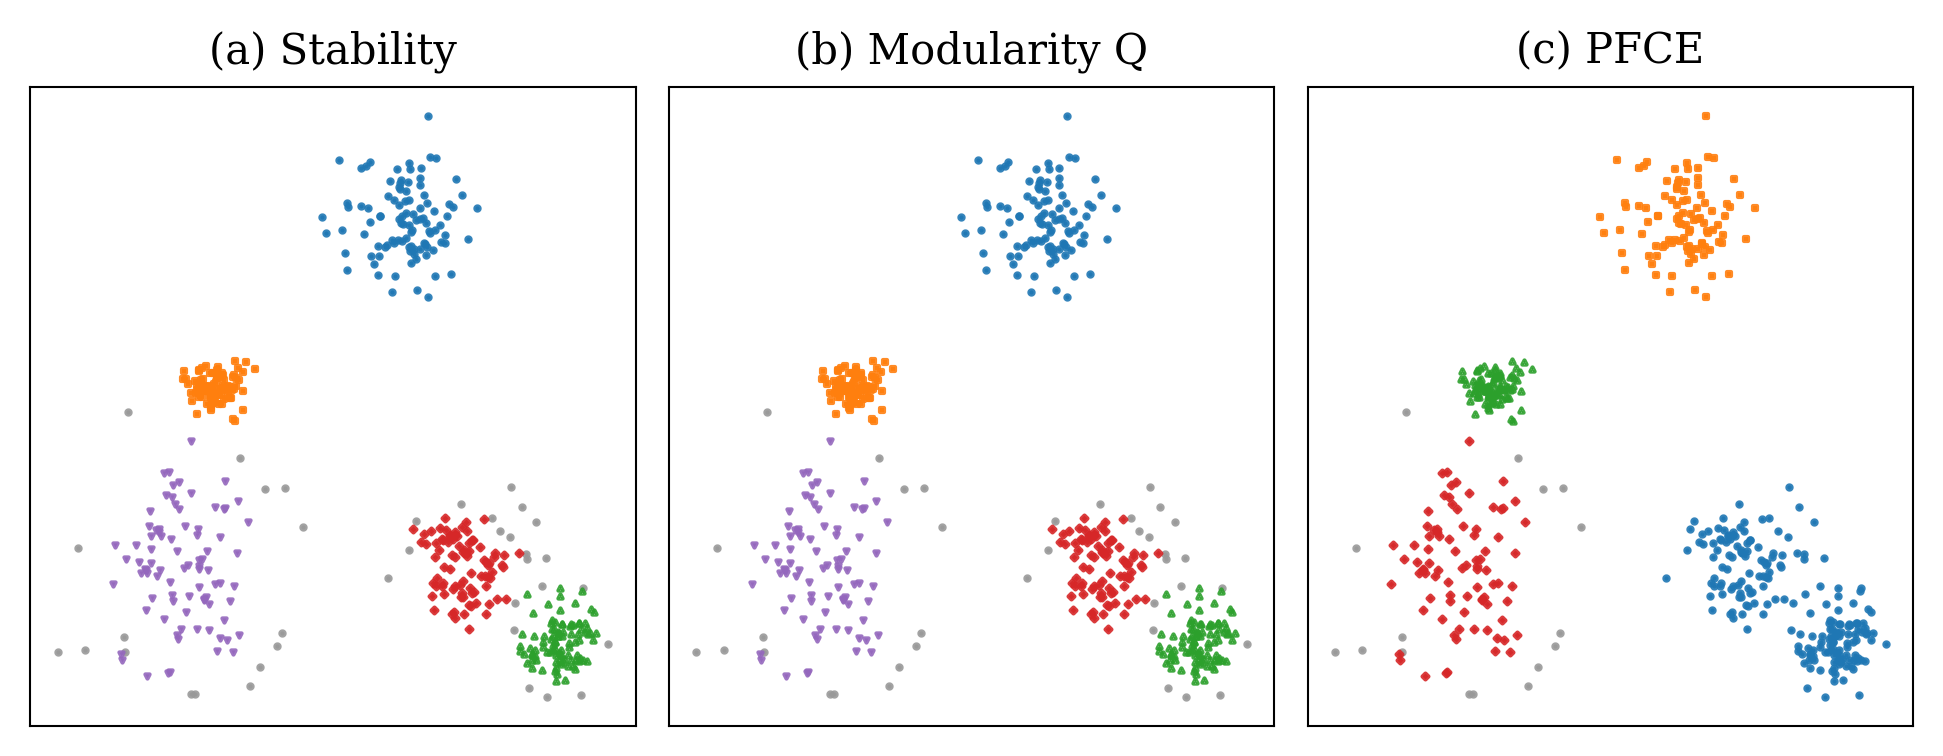

In [80]:
Y1 = model1.get_labels(0)
Y2 = model2.get_labels(0)
Y3 = model3.get_labels(0)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "figure.dpi": 300
})

fig = plt.figure(figsize=(6.5,2.8))
gs = GridSpec(1,3)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])

axes = [ax1, ax2, ax3]
label_sets = [Y1, Y2, Y3]

titles = [
    "(a) Stability",
    "(b) Modularity Q",
    "(c) PFCE"
]

# -------- cluster plots --------
for i, ax in enumerate(axes):

    plot_Clustering_2d(
        ax,
        X,
        label_sets[i],
        point_size=1
    )

    ax.set_title(titles[i])

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout(pad=0.8)

plt.savefig(
    "_static/example1.png",
    bbox_inches="tight"
)

plt.show()

In [81]:
seed = 5

rng = np.random.default_rng(seed)

X, _ = make_moons(n_samples=400, noise=0.05, random_state=seed)

# Use rng here 
bridge = rng.normal(loc=[0.5, 0.25], scale=0.11, size=(80, 2))

X = np.vstack([X, bridge])
# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSC(top_c=3,kmin=2, quality_measure="stability")
model2 = FOSC(top_c=3,kmin=2, quality_measure="modularity")
model3 = FOSC(top_c=3,kmin=2, quality_measure="PFCE")

model1.fit(Z)
print(model1.candidates_)
model2.fit(Z)
print(model2.candidates_)
model3.fit(Z)
print(model3.candidates_)



       quality  n_clusters                                     selected_nodes
0  1608.444741           4                               [483, 485, 486, 482]
1  1598.283721          12  [483, 485, 507, 515, 517, 521, 527, 528, 525, ...
2  1596.757553           5                          [483, 493, 494, 486, 482]
    quality  n_clusters                                 selected_nodes
0  0.621862           6                 [483, 485, 486, 487, 489, 490]
1  0.619899           8       [483, 485, 486, 487, 495, 499, 500, 490]
2  0.617277           9  [483, 485, 486, 487, 495, 505, 506, 500, 490]
    quality  n_clusters        selected_nodes
0  2.832230           3       [483, 484, 482]
1  2.804271           4  [483, 485, 486, 482]
2  2.737101           2            [481, 482]


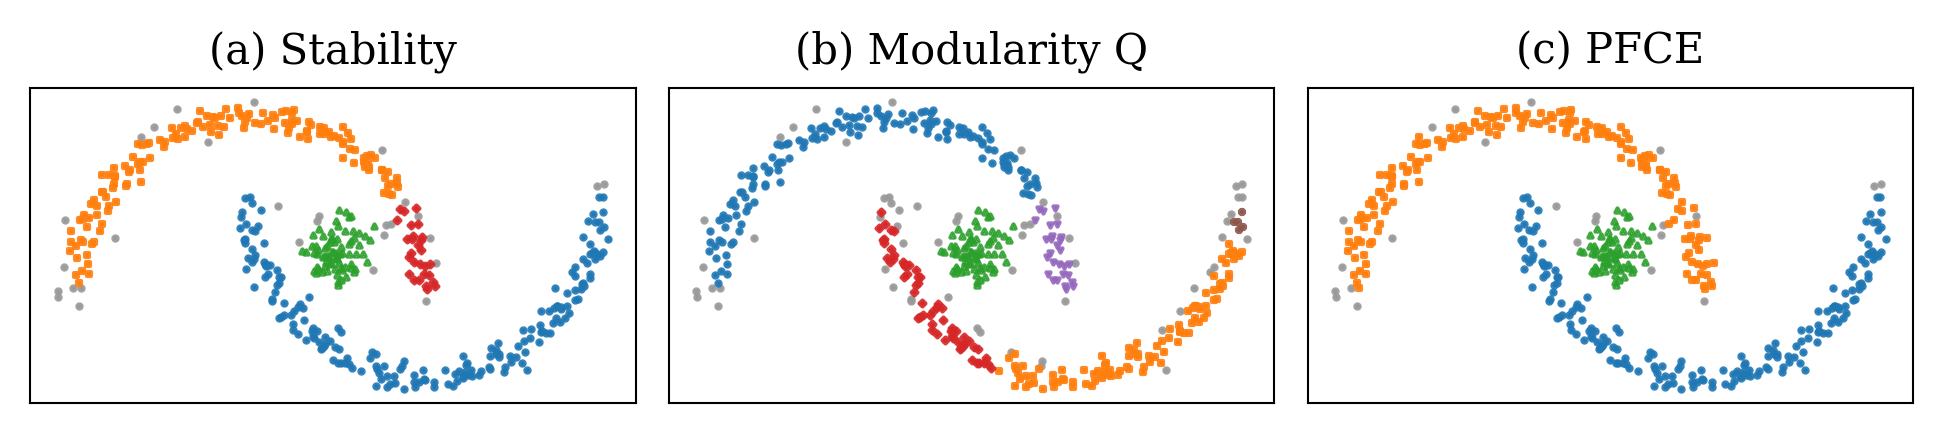

In [82]:
Y1 = model1.get_labels(0)
Y2 = model2.get_labels(0)
Y3 = model3.get_labels(0)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "figure.dpi": 300
})

fig = plt.figure(figsize=(6.5,2.8))
gs = GridSpec(1,3)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])

axes = [ax1, ax2, ax3]
label_sets = [Y1, Y2, Y3]

titles = [
    "(a) Stability",
    "(b) Modularity Q",
    "(c) PFCE"
]

# -------- cluster plots --------
for i, ax in enumerate(axes):

    plot_Clustering_2d(
        ax,
        X,
        label_sets[i],
        point_size=1
    )

    ax.set_title(titles[i])

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout(pad=0.8)

plt.savefig(
    "_static/example2.png",
    bbox_inches="tight"
)

plt.show()

In [83]:
X = np.load("clusterable_data.npy")
Z = hdbscan.HDBSCAN(min_cluster_size=5,gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSC(top_c=1,kmin=1, quality_measure="stability")
model2 = FOSC(top_c=1,kmin=1, quality_measure="modularity")
model3 = FOSC(top_c=1,kmin=1, quality_measure="PFCE")

model1.fit(Z)
print(model1.candidates_)
model2.fit(Z)
print(model2.candidates_)
model3.fit(Z)
print(model3.candidates_)

        quality  n_clusters                                     selected_nodes
0  29843.776741          39  [2315, 2323, 2363, 2362, 2365, 2364, 2360, 235...
    quality  n_clusters                                     selected_nodes
0  0.658286          17  [2315, 2323, 2351, 2350, 2348, 2373, 2372, 236...
   quality  n_clusters selected_nodes
0  2.58154           2   [2311, 2310]


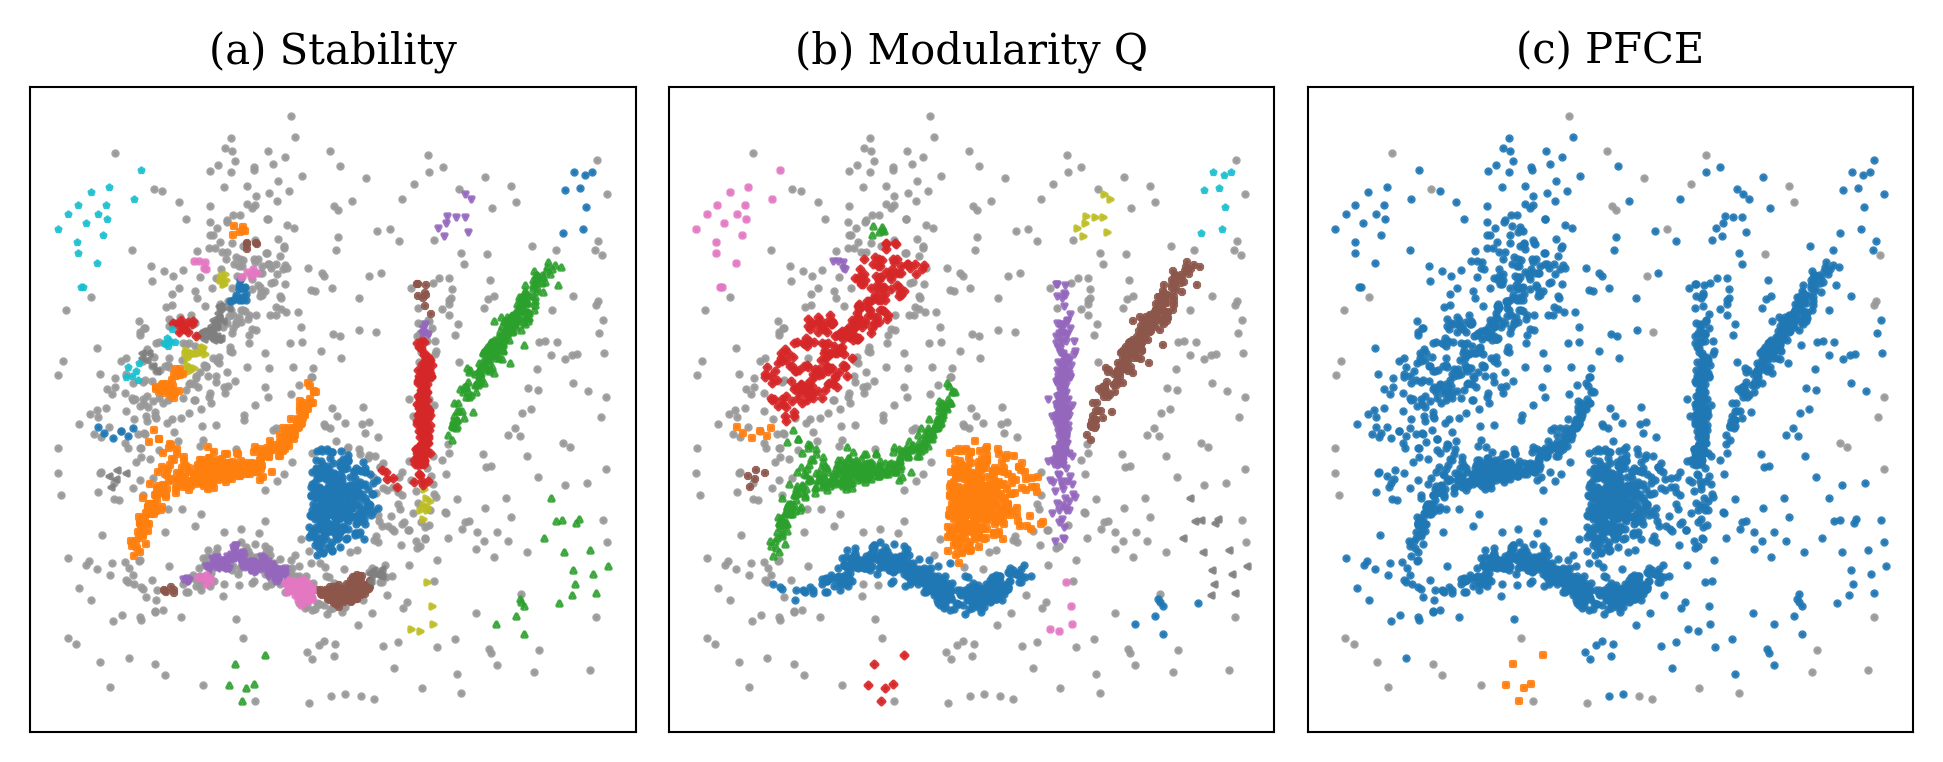

In [84]:
Y1 = model1.get_labels(0)
Y2 = model2.get_labels(0)
Y3 = model3.get_labels(0)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "figure.dpi": 300
})

fig = plt.figure(figsize=(6.5,2.8))
gs = GridSpec(1,3)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])

axes = [ax1, ax2, ax3]
label_sets = [Y1, Y2, Y3]

titles = [
    "(a) Stability",
    "(b) Modularity Q",
    "(c) PFCE"
]

# -------- cluster plots --------
for i, ax in enumerate(axes):

    plot_Clustering_2d(
        ax,
        X,
        label_sets[i],
        point_size=1
    )

    ax.set_title(titles[i])

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout(pad=0.8)

plt.savefig(
    "_static/example3.png",
    bbox_inches="tight"
)

plt.show()

In [85]:
seed = 23
rng = np.random.default_rng(seed)
X, _ = make_blobs(500, 2, centers=5,cluster_std=np.abs(rng.normal([0.5,0.5,0.5,0.5,0.5])),random_state=seed)

# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSC(top_c=3,kmin=2, quality_measure="stability")


model1.fit(Z)


,top_c,3
,kmin,2
,kmax,None
,min_cluster_size,5
,quality_measure,'stability'
,singletons_as_noise,False
,keep_noise_quality,None
,nearest_neighbors,None
,metric,'euclidean'
,density,True


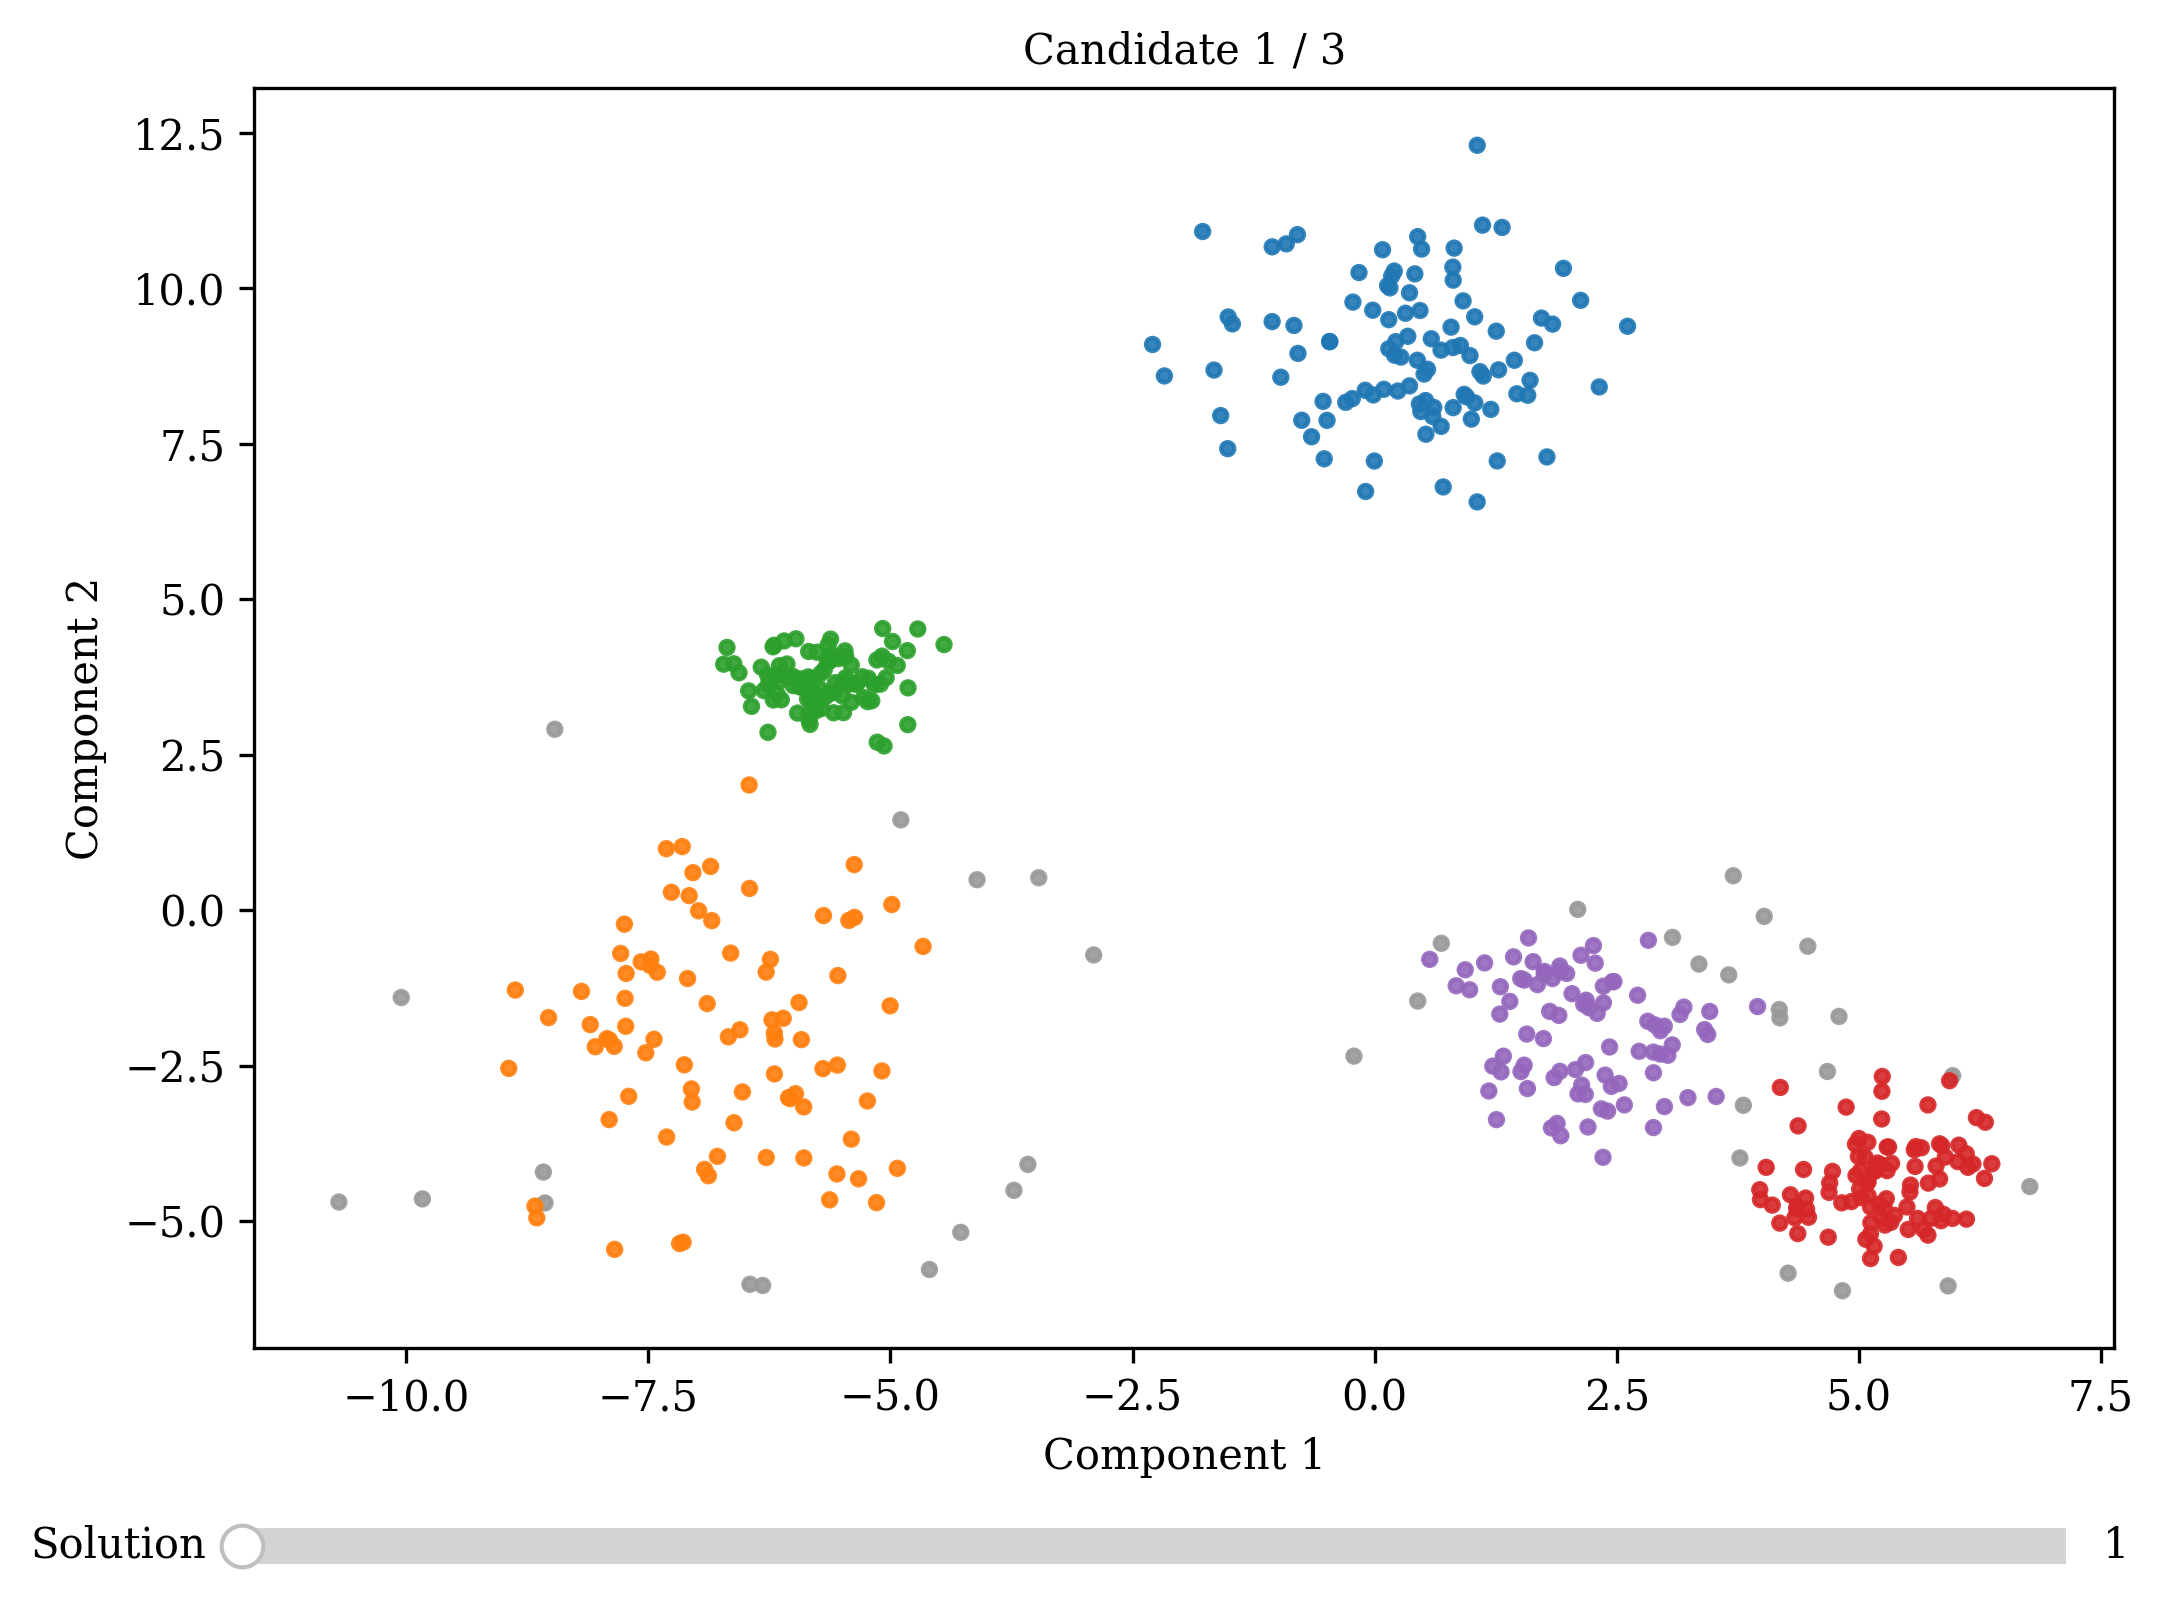

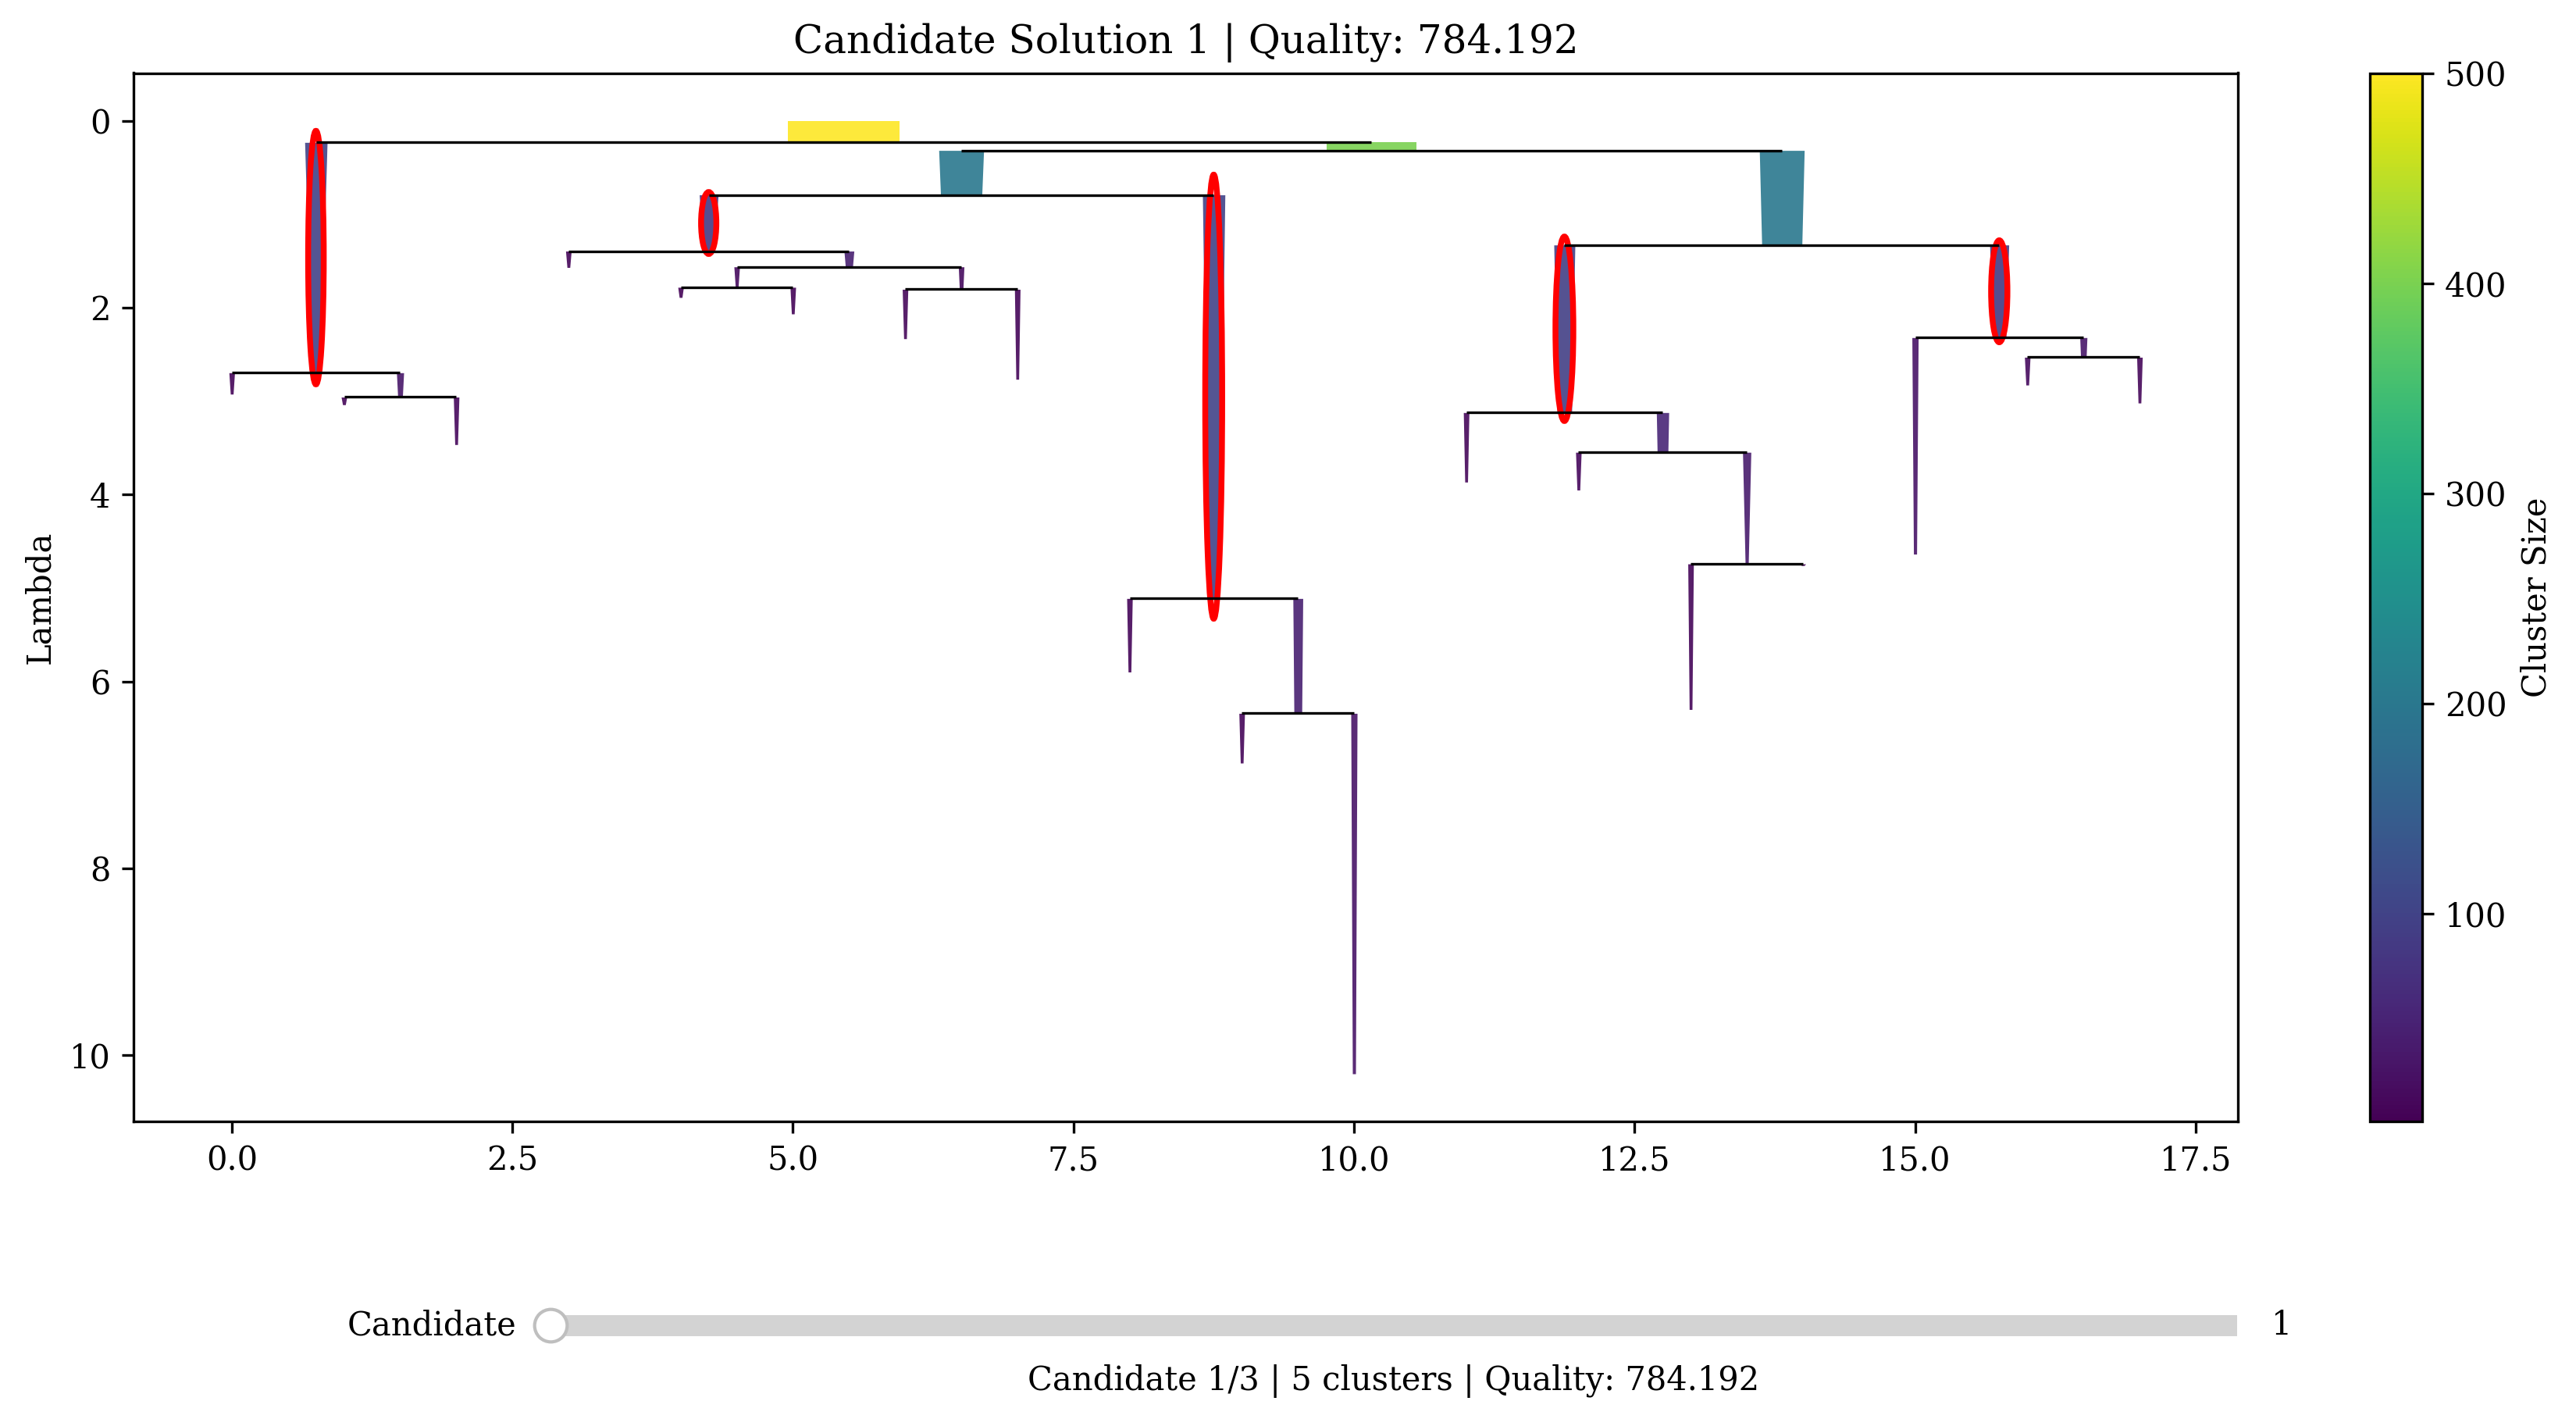

(<Figure size 3600x1800 with 4 Axes>,
 <Axes: title={'center': 'Candidate Solution 1 | Quality: 784.192'}, ylabel='Lambda'>)

In [89]:
model1.plot()
model1.plot_tree()
